# Analyzes mean and avg of the GENERATED connectomes 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

def quality_check_regarding_means_and_avgs(path_to_csv_file, bin_into_100=True):
    path_to_csv_file = Path(path_to_csv_file)
    df = pd.read_csv(path_to_csv_file)

    # Define the columns to analyze (excluding eta, gamma, and other metadata)
    metric_columns = [
        'MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)',
        'avg_communicability',
        'global_efficiency',
        'modularity',
        'avg_clustering',
        'transitivity',
        'avg_edge_distance',
        'wiring_cost',
        'char_path_length',
        'richclub_n_edges',
        'richclub_avg_length', 
        
        # "avg_degree",
        # "degree_assortativity",
        # "shortest_path_distance_mean",
        # "shortest_path_distance_std",
        # "structural_complexity",
        # "n_connected_components",
        # "topological_distance_mean",
        # "topological_distance_std",
        # "degree_gini",
        # "spectral_radius",
        # "spectral_gap",
        # "spectral_gap_fatemeh",
        # "diffusion_efficiency",
        # "propagation_efficiency",
        # "nct_control_avg",
        # "nct_control_std",
        # "nct_control_n_nodes_90_percent",
        # "nct_control_n_nodes_50_percent",
        # "nct_energies_energy_total",
        # "nct_energies_std_node_energy",
        # "nct_energies_n_nodes_90_percent",
        # "nct_energies_n_nodes_50_percent",
        # "metastability_global",
        # "metastability_local_mean",
        # "metastability_local_std",
        # "metastability_local_kurtosis",
        # "kernel_rank",
        # "kernel_rank_fatemeh",
        # "effective_dimensionality",
        # "multifunctionality"
    ]

    # Group by eta and gamma, then calculate mean and std for each metric. Group into 100 bins for eta and gamma first!
    if bin_into_100: 
        df['eta'] = pd.cut(df['eta'], bins=100, labels=False)
        df['gamma'] = pd.cut(df['gamma'], bins=100, labels=False)
    # Group by eta and gamma, then calculate mean and std for each metric
    grouped = df.groupby(['eta', 'gamma'])[metric_columns].agg(['mean', 'std']).reset_index()

    # Display the grouped statistics
    print("Grouped Statistics by Eta and Gamma:")
    print(grouped)
    print(f"\nNumber of unique eta-gamma combinations: {len(grouped)}")

    # Prepare data for heatmaps
    output_folder = path_to_csv_file.parent / 'heatmaps_mean_and_std/'
    os.makedirs(output_folder, exist_ok=True)

    # plot it
    things = ["mean", "std", "std_dev_normalized_by_mean"]
    for metric in metric_columns:
        for thing in things:
            plt.figure(figsize=(10, 8))
            pivot_table = grouped.pivot(index='eta', columns='gamma', values=(metric, thing if thing != "std_dev_normalized_by_mean" else 'std'))
            if thing == "std_dev_normalized_by_mean":
                pivot_table = pivot_table / grouped.pivot(index='eta', columns='gamma', values=(metric, 'mean'))
            sns.heatmap(pivot_table, # annot=True, 
                        fmt=".2f", cmap="Blues") # YlGnBu")
            
            # Invert y-axis
            plt.gca().invert_yaxis()

            plt.title(f'[{metric.replace("_", " ").title()}] - {thing.replace("_", " ").title()}') #  by Eta and Gamma')
            plt.xlabel('Gamma (rounded)')
            plt.ylabel('Eta (rounded)')
            
            # Make ticks readable
            distance = 10
            plt.xticks(ticks=np.arange(len(pivot_table.columns)//distance)*distance, labels=[f"{x:.1f}" for x in pivot_table.columns[::distance]])  # Show not every label
            plt.yticks(ticks=np.arange(len(pivot_table.index)//distance)*distance, labels=[f"{y:.1f}" for y in pivot_table.index[::distance]])  # Show not every label

            plt.savefig(output_folder / f'{metric}_{thing}.pdf')
            plt.show()
        
        
    # Similar to the style above: Plot how many samples went into each point in the heatmap
    plt.figure(figsize=(10, 8))
    count_pivot_table = df.groupby(['eta', 'gamma']).size().unstack(fill_value=0)
    sns.heatmap(count_pivot_table, # annot=True, 
                fmt="d", cmap="Greens")
    plt.title('Number of Samples by Eta and Gamma')
    plt.xlabel('Gamma (rounded)')
    plt.ylabel('Eta (rounded)')   
    
    # Change ticks to not have the bin numbers but the actual ranges
    plt.xticks(ticks=np.arange(len(pivot_table.columns)), labels=[f"{x:.1f}" for x in pivot_table.columns])
    plt.yticks(ticks=np.arange(len(pivot_table.index)), labels=[f"{y:.1f}" for y in pivot_table.index])
    
    # Make ticks readable
    distance = 10
    plt.xticks(ticks=np.arange(len(count_pivot_table.columns)//distance)*distance, labels=[f"{x:.1f}" for x in count_pivot_table.columns[::distance]])  # Show not every label
    plt.yticks(ticks=np.arange(len(count_pivot_table.index)//distance)*distance, labels=[f"{y:.1f}" for y in count_pivot_table.index[::distance]])  # Show not every label
    plt.savefig(output_folder / f'count_samples.pdf')
    plt.show()


In [7]:
# Read the CSV file
path_to_csv_file = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/75_10000_samples_hopefully_no_lost_entries_gamma_-0p1_to_1_animal_206/all_metrics_for_75_10000_samples_hopefully_no_lost_entries_gamma_-0p1_to_1_animal_206_all.csv"
path_to_csv_file = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/63_fine_grid_animal_0/all_metrics_for_63_fine_grid_animal_0.csv"
# quality_check_regarding_means_and_avgs(path_to_csv_file, bin_into_100=False) 


Grouped Statistics by Eta and Gamma:
     eta gamma  \
                 
0      0     0   
1      0     1   
2      0     2   
3      0     3   
4      0     4   
...   ..   ...   
9995  99    95   
9996  99    96   
9997  99    97   
9998  99    98   
9999  99    99   

     MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)  \
                                                                 mean   
0                                              0.369921                 
1                                              0.384736                 
2                                              0.369248                 
3                                              0.372391                 
4                                              0.375758                 
...                                                 ...                 
9995                                           0.406667                 
9996                                           0.400000                

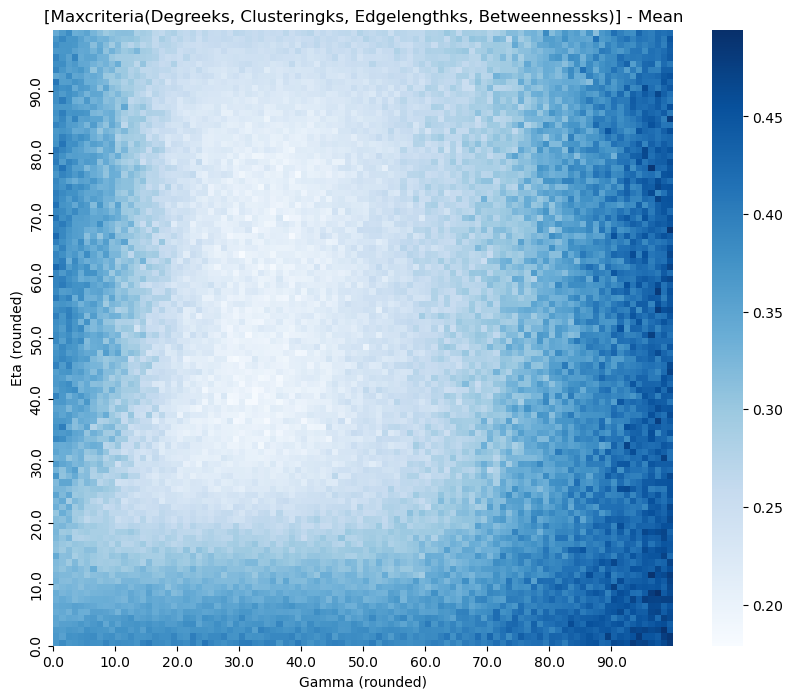

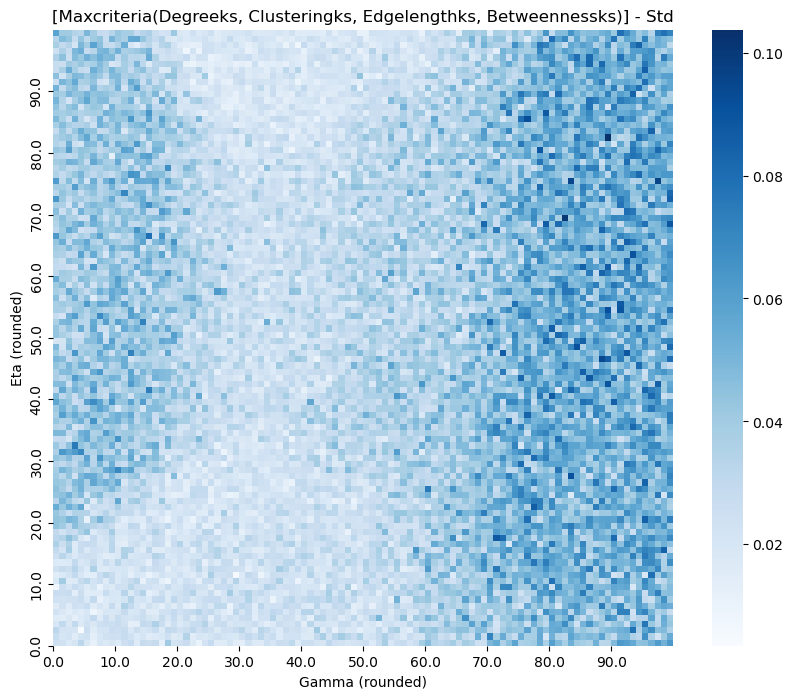

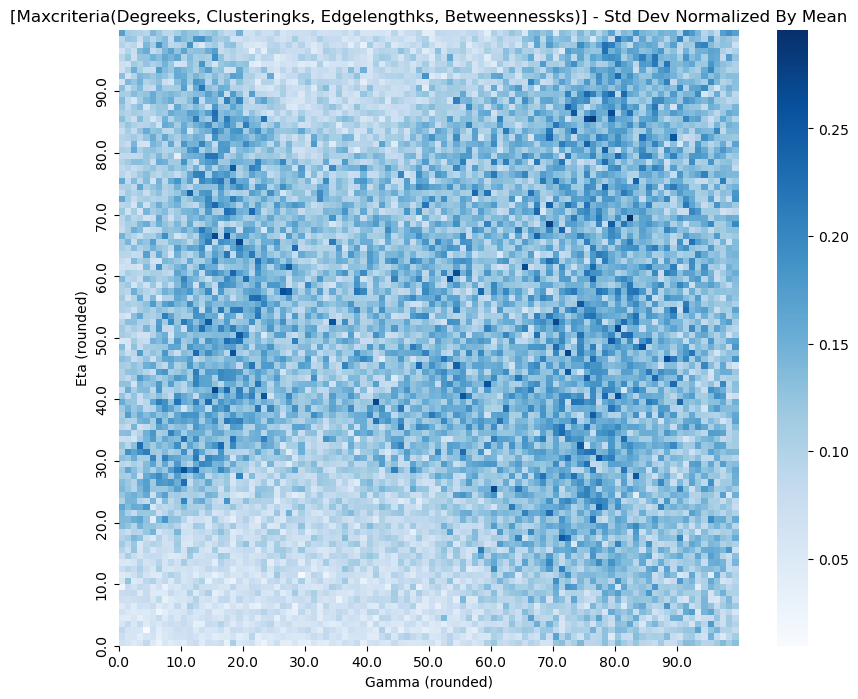

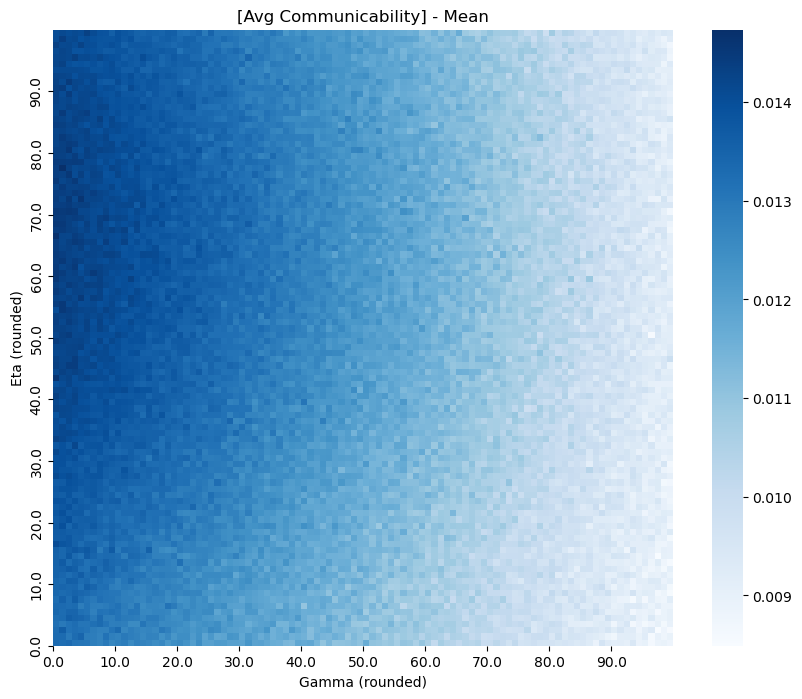

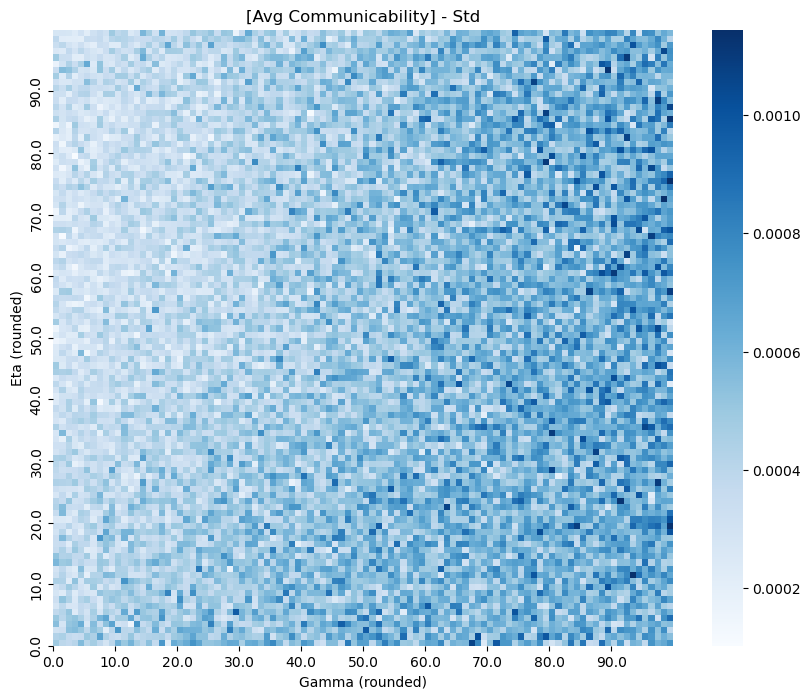

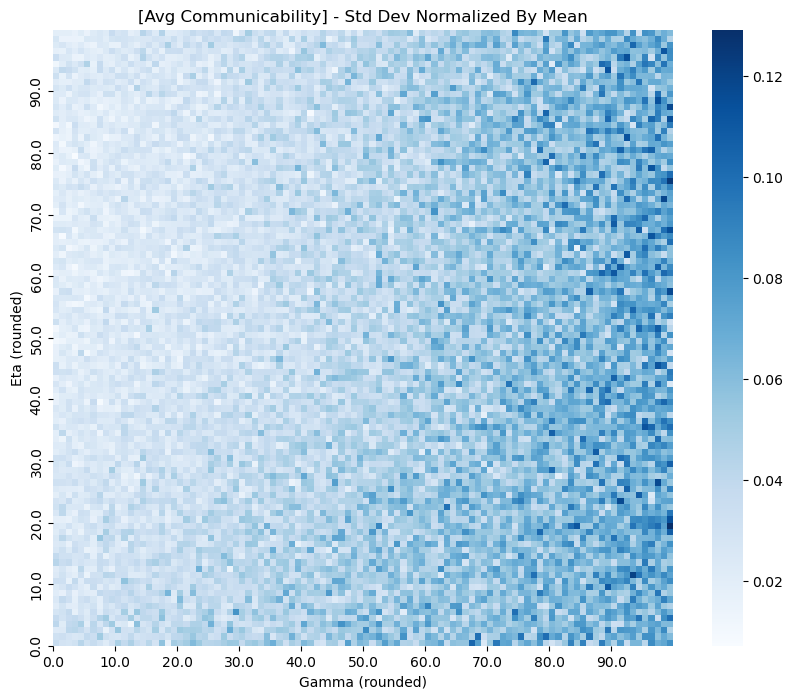

KeyboardInterrupt: 

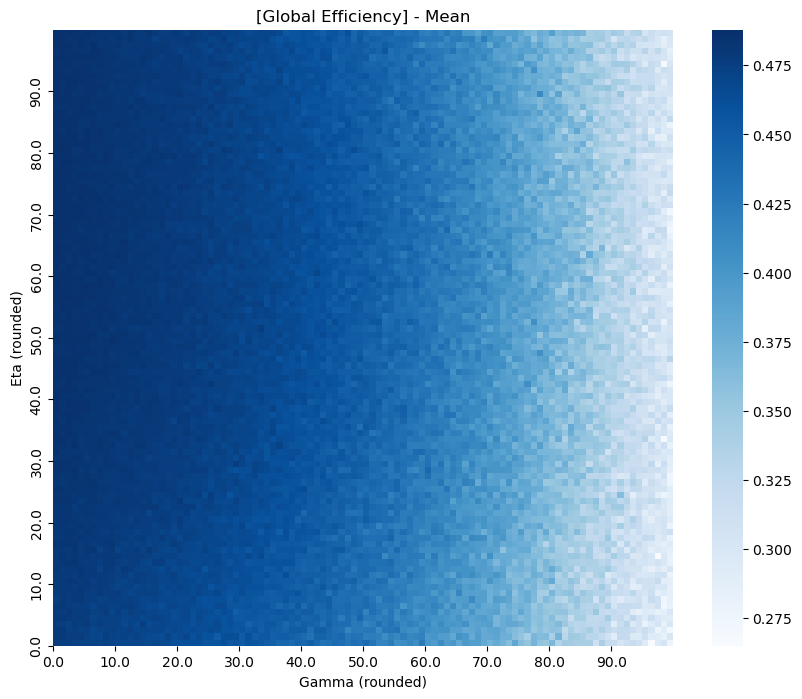

In [8]:

path_to_csv_file = Path(path_to_csv_file)
df = pd.read_csv(path_to_csv_file)

# Define the columns to analyze (excluding eta, gamma, and other metadata)
metric_columns = [
    'MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)',
    'avg_communicability',
    'global_efficiency',
    'modularity',
    'avg_clustering',
    'transitivity',
    'avg_edge_distance',
    'wiring_cost',
    'char_path_length',
    'richclub_n_edges',
    'richclub_avg_length'
]

# Group by eta and gamma, then calculate mean and std for each metric. Group into 100 bins for eta and gamma first!

df['eta'] = pd.cut(df['eta'], bins=100, labels=False)
df['gamma'] = pd.cut(df['gamma'], bins=100, labels=False)
# Group by eta and gamma, then calculate mean and std for each metric
grouped = df.groupby(['eta', 'gamma'])[metric_columns].agg(['mean', 'std']).reset_index()

# Display the grouped statistics
print("Grouped Statistics by Eta and Gamma:")
print(grouped)
print(f"\nNumber of unique eta-gamma combinations: {len(grouped)}")

# Prepare data for heatmaps
output_folder = path_to_csv_file.parent / 'heatmaps_mean_and_std/'
os.makedirs(output_folder, exist_ok=True)

# plot it
things = ["mean", "std", "std_dev_normalized_by_mean"]
for metric in metric_columns:
    for thing in things:
        plt.figure(figsize=(10, 8))
        pivot_table = grouped.pivot(index='eta', columns='gamma', values=(metric, thing if thing != "std_dev_normalized_by_mean" else 'std'))
        if thing == "std_dev_normalized_by_mean":
            pivot_table = pivot_table / grouped.pivot(index='eta', columns='gamma', values=(metric, 'mean'))
        sns.heatmap(pivot_table, # annot=True, 
                    fmt=".2f", cmap="Blues") # YlGnBu")
        
        # Invert y-axis
        plt.gca().invert_yaxis()

        plt.title(f'[{metric.replace("_", " ").title()}] - {thing.replace("_", " ").title()}') #  by Eta and Gamma')
        plt.xlabel('Gamma (rounded)')
        plt.ylabel('Eta (rounded)')
        
        # Change ticks to not have the bin numbers but the actual ranges
        plt.xticks(ticks=np.arange(len(pivot_table.columns)), labels=[f"{x:.1f}" for x in pivot_table.columns])
        plt.yticks(ticks=np.arange(len(pivot_table.index)), labels=[f"{y:.1f}" for y in pivot_table.index])
        
        # Make ticks readable
        distance = 10
        plt.xticks(ticks=np.arange(len(pivot_table.columns)//distance)*distance, labels=[f"{x:.1f}" for x in pivot_table.columns[::distance]])  # Show not every label
        plt.yticks(ticks=np.arange(len(pivot_table.index)//distance)*distance, labels=[f"{y:.1f}" for y in pivot_table.index[::distance]])  # Show not every label

        plt.savefig(output_folder / f'{metric}_{thing}.pdf')
        plt.show()
    
    
# Similar to the style above: Plot how many samples went into each point in the heatmap
plt.figure(figsize=(10, 8))
count_pivot_table = df.groupby(['eta', 'gamma']).size().unstack(fill_value=0)
sns.heatmap(count_pivot_table, # annot=True, 
            fmt="d", cmap="Greens")
plt.title('Number of Samples by Eta and Gamma')
plt.xlabel('Gamma (rounded)')
plt.ylabel('Eta (rounded)')     
# Make ticks readable
distance = 10
plt.xticks(ticks=np.arange(len(count_pivot_table.columns)//distance)*distance, labels=[f"{x:.1f}" for x in count_pivot_table.columns[::distance]])  # Show not every label
plt.yticks(ticks=np.arange(len(count_pivot_table.index)//distance)*distance, labels=[f"{y:.1f}" for y in count_pivot_table.index[::distance]])  # Show not every label
# plt.savefig(output_folder / f'count_samples.pdf')
plt.show()


# Individual fits

Grouped Statistics by Eta and Gamma:
     eta_bin gamma_bin MaxCrit_indiv_0           MaxCrit_indiv_1            \
                                  mean       std            mean       std   
0          0         0        0.655000  0.007071        0.670000  0.014142   
1          0         1        0.656667  0.020817        0.676667  0.015275   
2          0         2        0.640000       NaN        0.640000       NaN   
3          0         3        0.665000  0.034156        0.680000  0.037417   
4          0         4        0.640000  0.026458        0.663333  0.025166   
...      ...       ...             ...       ...             ...       ...   
9574      98        93        0.902000  0.102811        0.918000  0.112339   
9575      98        94        0.892857  0.069693        0.911429  0.084741   
9576      98        96        0.914000  0.037815        0.928000  0.049699   
9577      98        97        0.852500  0.068007        0.857500  0.101776   
9578      98        98     

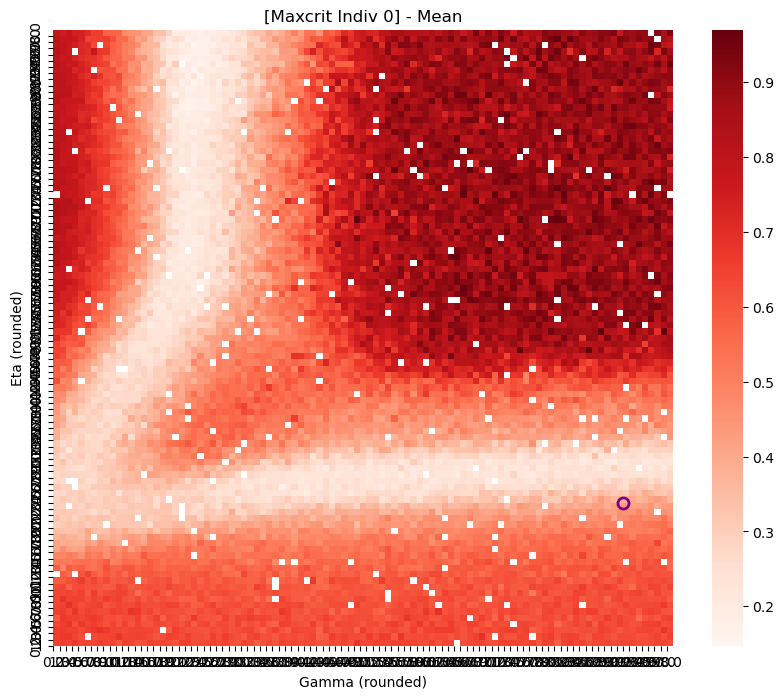

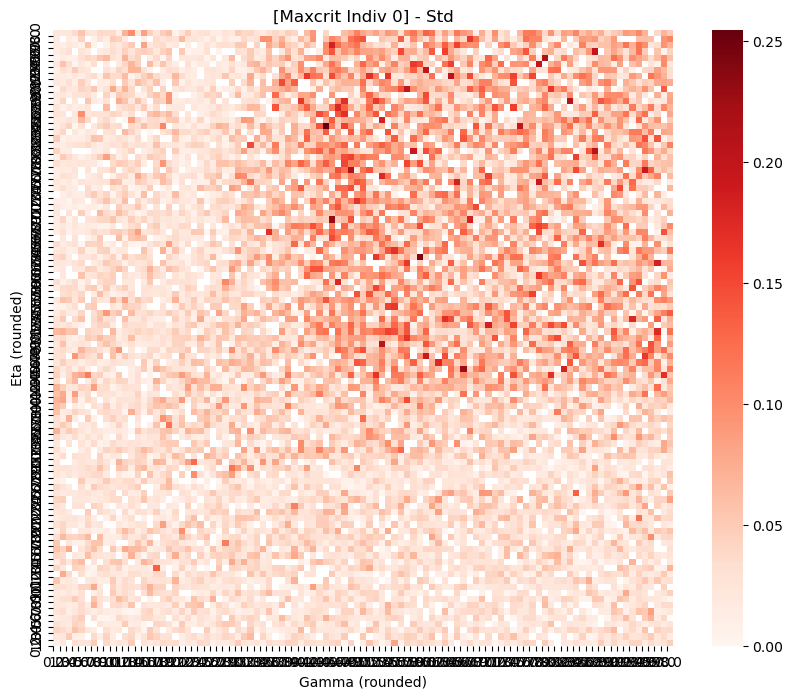

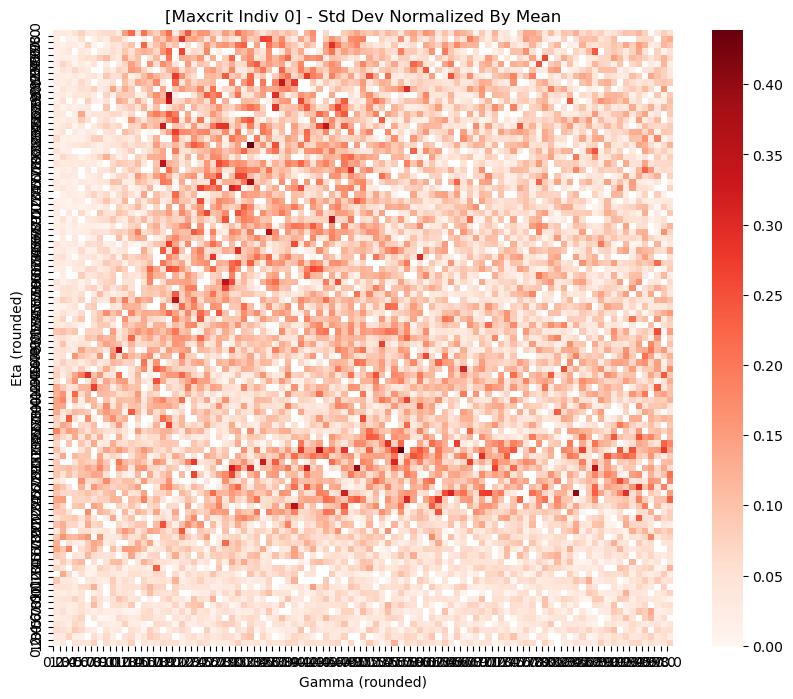

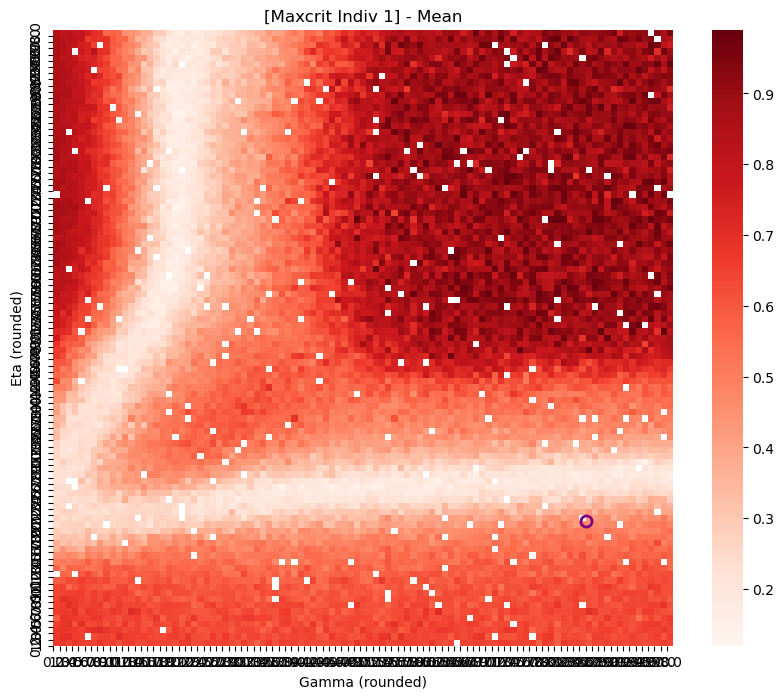

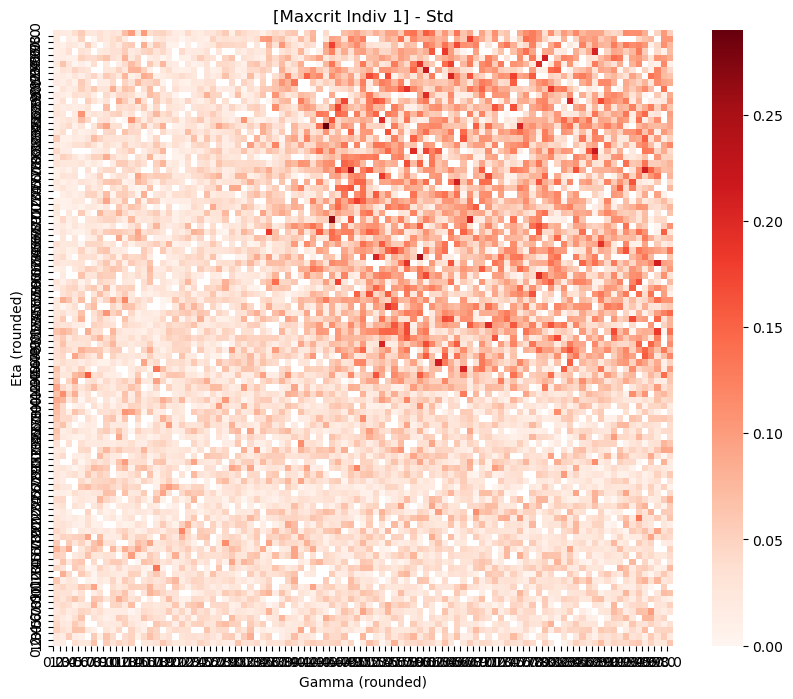

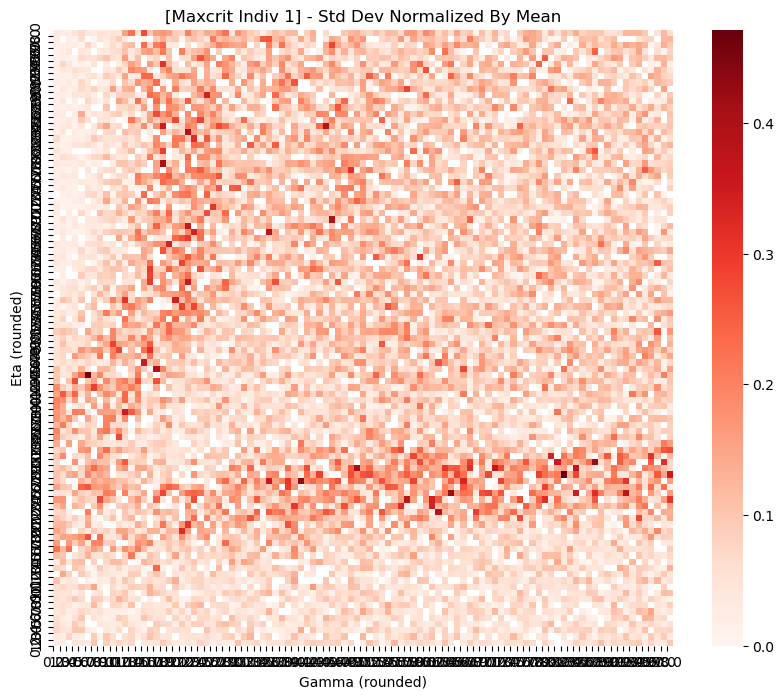

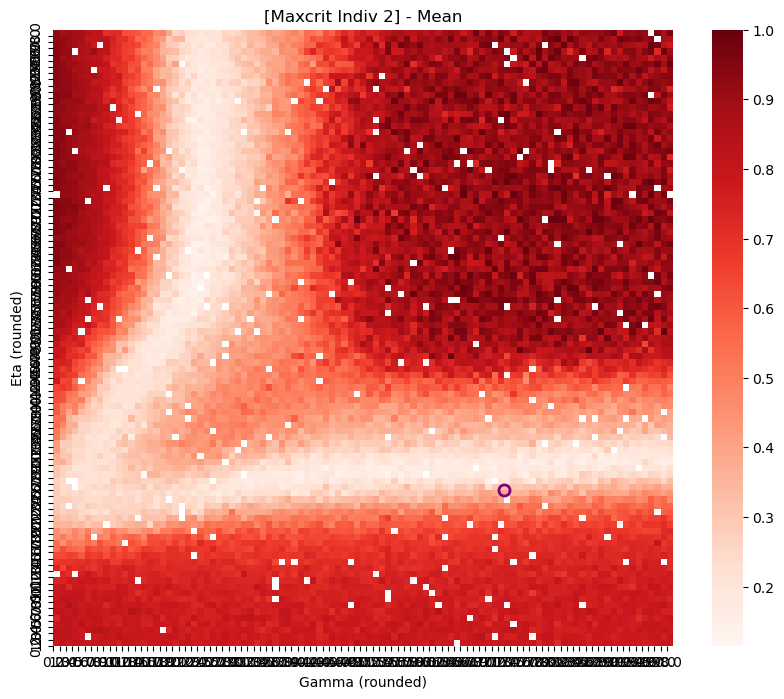

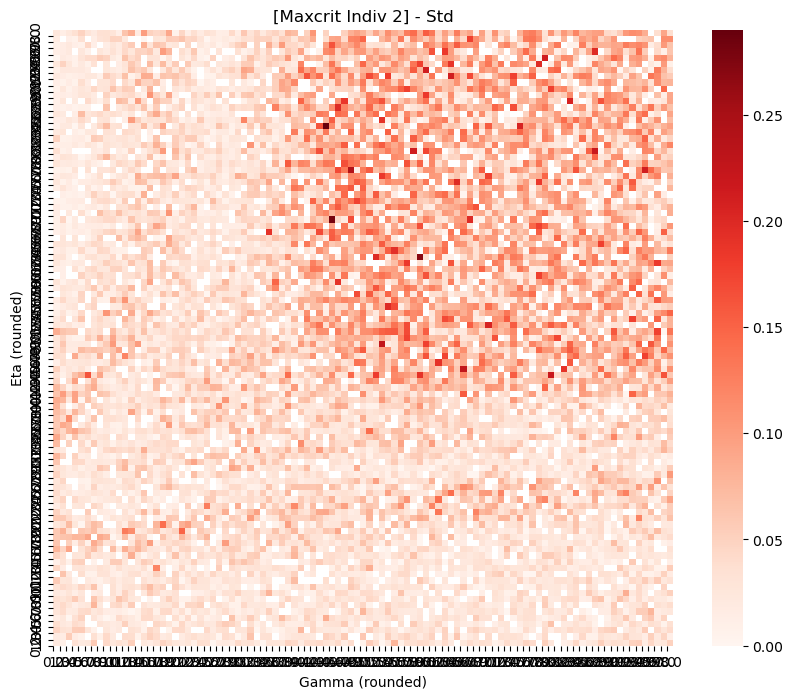

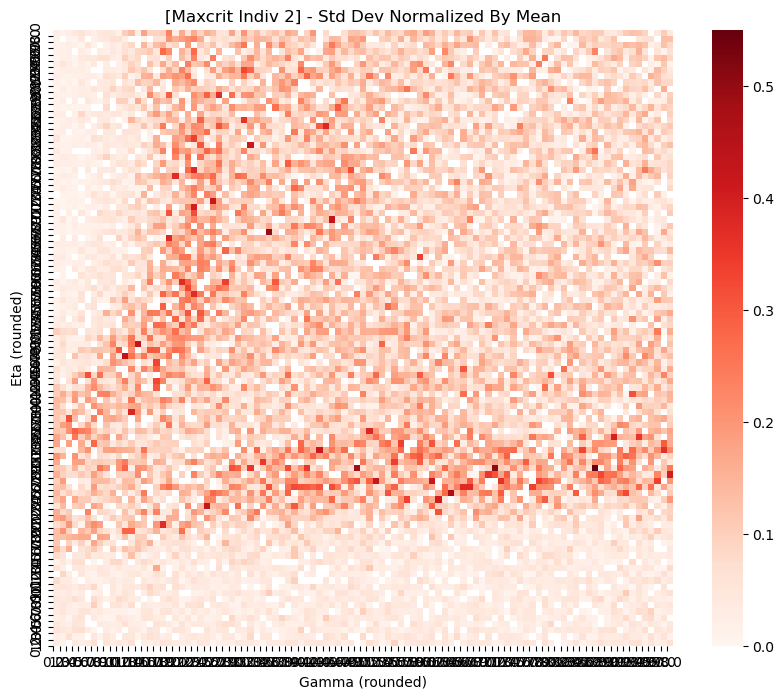

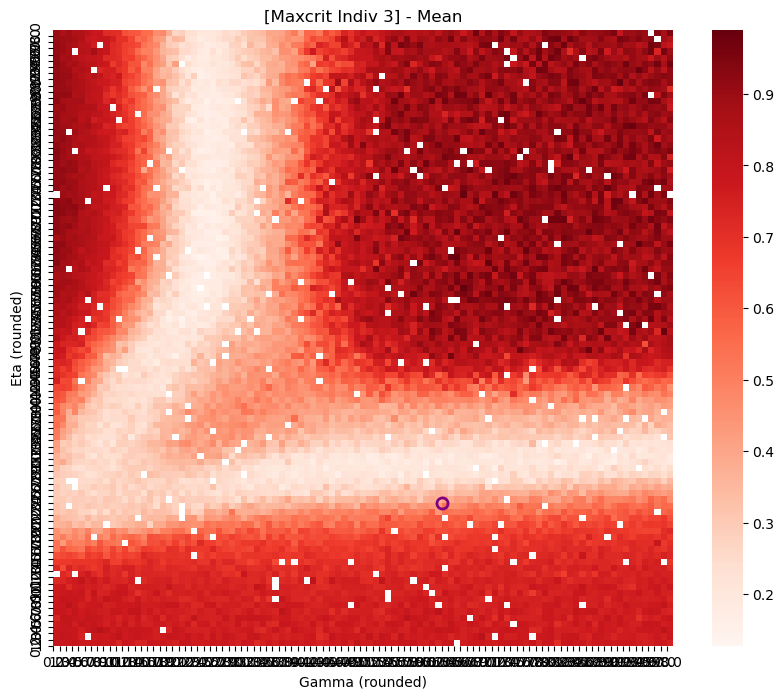

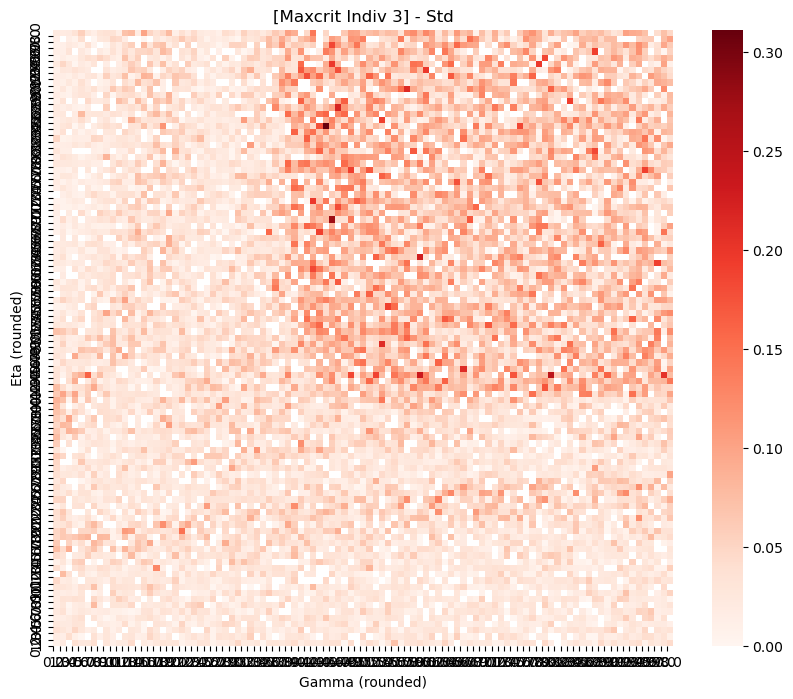

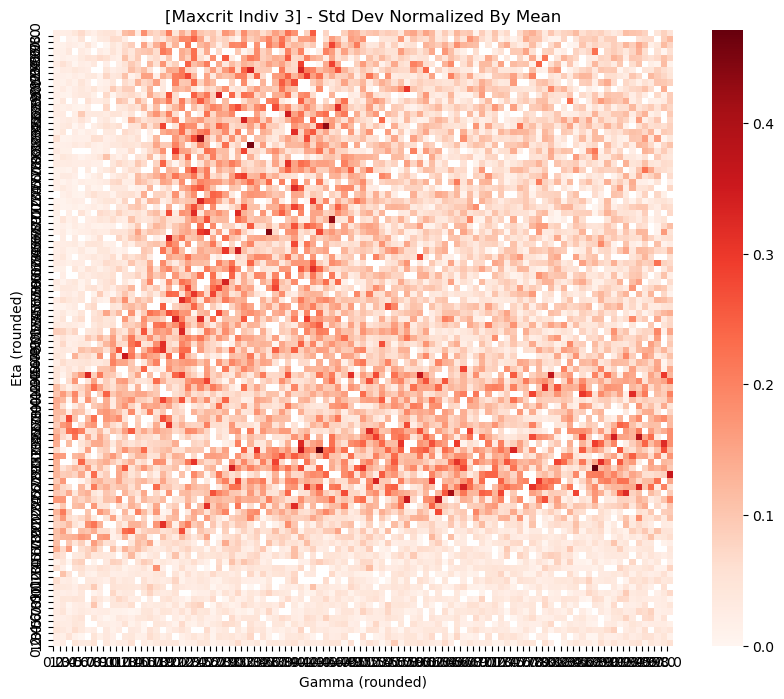

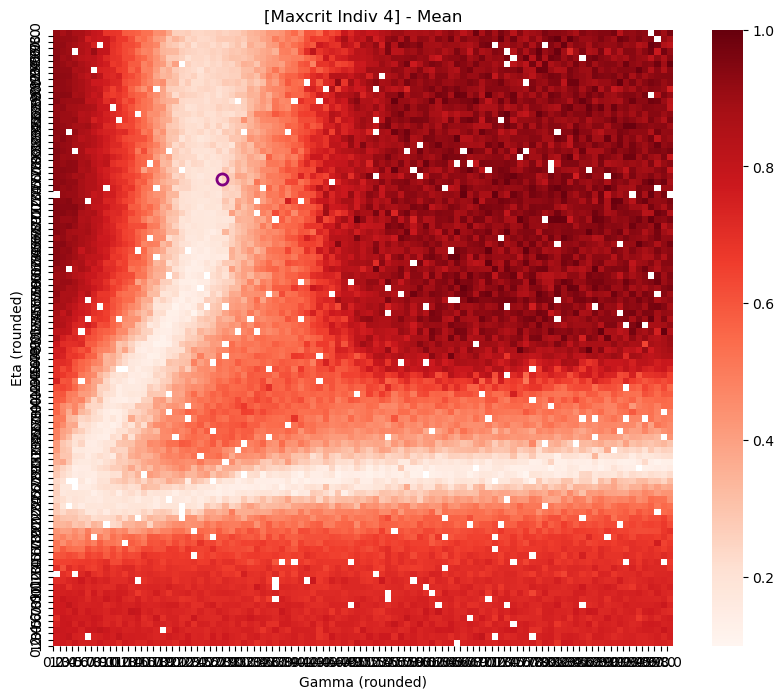

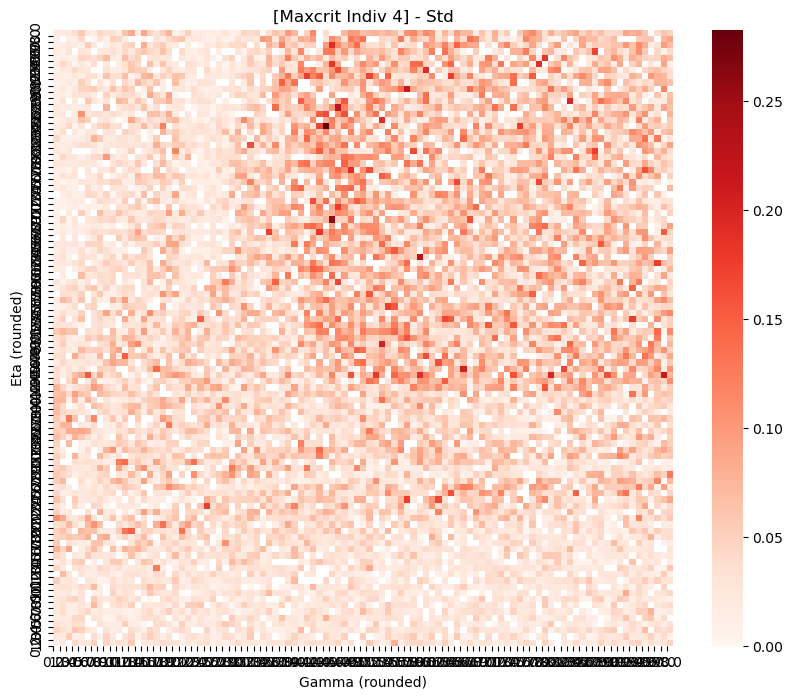

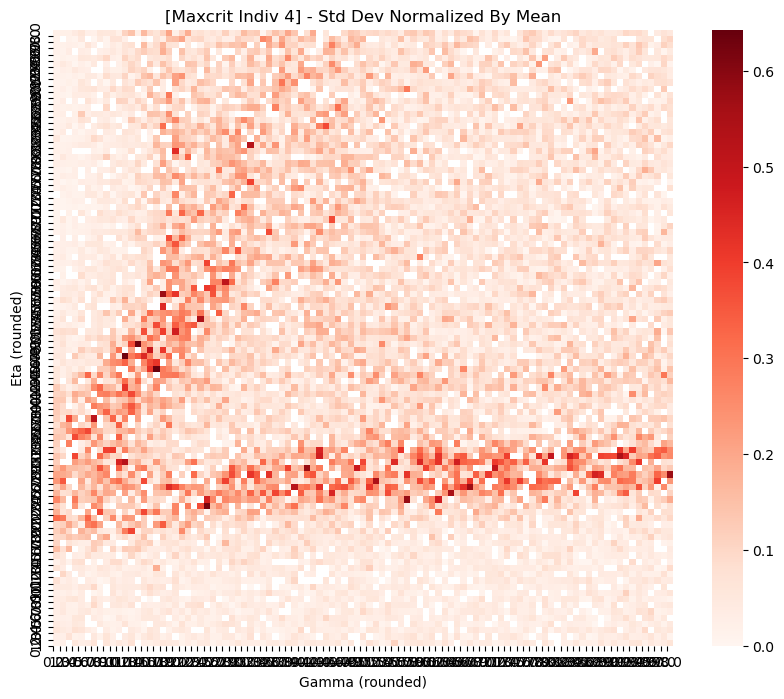

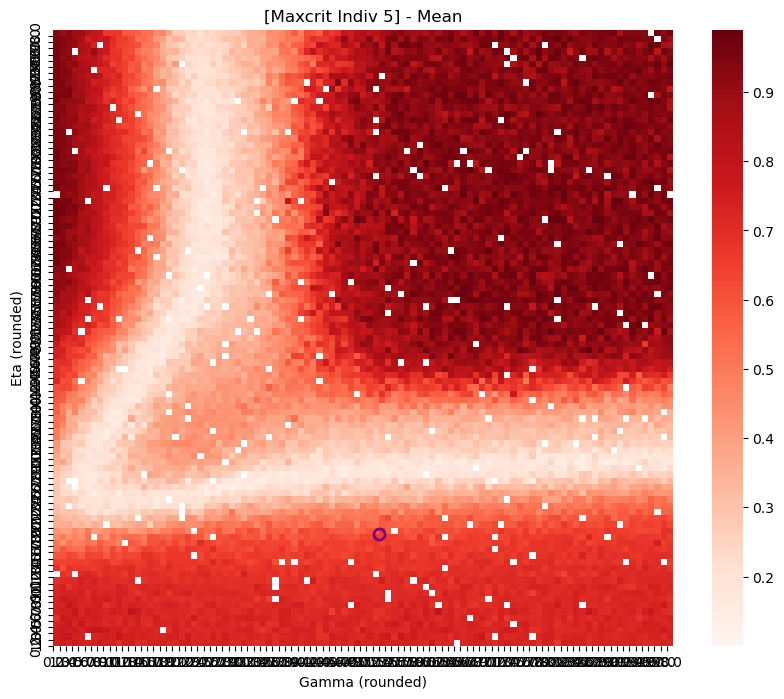

KeyboardInterrupt: 

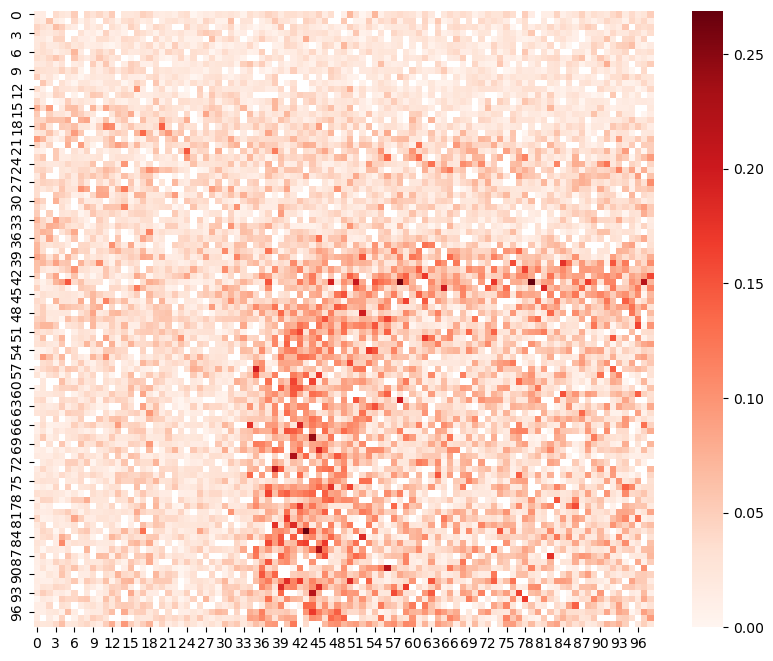

In [36]:
# path_to_csv_file = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/70_mix_and_match_animal_0/summary_indiv_energies_for_exp_70_mix_and_match_animal_0.csv"
path_to_csv_file = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/summary_indiv_energies_for_exp_76_90000_samples_animal_206.csv"  
# "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/summary_indiv_energies_for_exp_76_90000_samples_animal_206.csv"
path_to_csv_file = Path(path_to_csv_file)
df = pd.read_csv(path_to_csv_file)

# path_to_csv_file = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/summary_indiv_energies_for_exp_76_90000_samples_animal_206.csv"
# path_to_csv_file = Path(path_to_csv_file)
# df = pd.read_csv(path_to_csv_file)

# Define the columns to analyze (excluding eta, gamma, and other metadata)
metric_columns = df.keys().tolist()
metric_columns.remove('eta') 
metric_columns.remove('gamma')
if "id" in metric_columns:
    metric_columns.remove('id')
metric_columns.remove('network_index')
metric_columns.remove('filename')


# Group by eta and gamma, then calculate mean and std for each metric. Group into 100 bins for eta and gamma first!

df['eta_bin'] = pd.cut(df['eta'], bins=99, labels=False)
df['gamma_bin'] = pd.cut(df['gamma'], bins=99, labels=False)
# Group by eta and gamma, then calculate mean and std for each metric
grouped = df.groupby(['eta_bin', 'gamma_bin'])[metric_columns].agg(['mean', 'std']).reset_index()

# Display the grouped statistics
print("Grouped Statistics by Eta and Gamma:")
print(grouped)
print(f"\nNumber of unique eta-gamma combinations: {len(grouped)}")

# Prepare data for heatmaps
output_folder = path_to_csv_file.parent / 'heatmaps_mean_and_std_but_for_individual_fits/'
os.makedirs(output_folder, exist_ok=True)



print(output_folder)
# plot it
things = ["mean", "std", "std_dev_normalized_by_mean"]
for metric in metric_columns:
    for thing in things:
        plt.figure(figsize=(10, 8))
        pivot_table = grouped.pivot(index='eta_bin', columns='gamma_bin', values=(metric, thing if thing != "std_dev_normalized_by_mean" else 'std'))
        if thing == "std_dev_normalized_by_mean":
            pivot_table = pivot_table / grouped.pivot(index='eta_bin', columns='gamma_bin', values=(metric, 'mean'))
        sns.heatmap(pivot_table, # annot=True, 
                    fmt=".2f", cmap="Reds") # Blues") # YlGnBu")
        # scatter points for the minimum and maximum values
        if thing == "mean":
            # Or using numpy (faster for large tables)
            min_value = pivot_table.values.min()

            # Get the location of the minimum
            min_location = pivot_table.stack().idxmin()  # Returns (row_label, col_label)

            # # Or get row and column indices for plotting
            # min_row_idx = pivot_table.values.argmin() // pivot_table.shape[1]
            # min_col_idx = pivot_table.values.argmin() % pivot_table.shape[1]  
            
            # Mark the minimum with a marker
            plt.plot(min_location[0], min_location[1], 'o', markersize=8, # , color=None,
                    #  alpha = 0.0, 
                    # facecolors='none',
                    markerfacecolor='none',
                    markeredgecolor='purple', markeredgewidth=2)
  
        # Invert y-axis
        plt.gca().invert_yaxis()

        plt.title(f'[{metric.replace("_", " ").title()}] - {thing.replace("_", " ").title()}') #  by Eta and Gamma'
        plt.xlabel('Gamma (rounded)')
        plt.ylabel('Eta (rounded)')
        
        # Change ticks to not have the bin numbers but the actual ranges
        plt.xticks(ticks=np.arange(len(pivot_table.columns)), labels=[f"{x:.1f}" for x in pivot_table.columns])
        plt.yticks(ticks=np.arange(len(pivot_table.index)), labels=[f"{y:.1f}" for y in pivot_table.index])
        
        # Make ticks readable
        distance = 10
        # plt.xticks(ticks=np.arange(len(pivot_table.columns)//distance)*distance, labels=[f"{x:.1f}" for x in pivot_table.columns[::distance]])  # Show not every label
        # plt.yticks(ticks=np.arange(len(pivot_table.index)//distance)*distance, labels=[f"{y:.1f}" for y in pivot_table.index[::distance]])  # Show not every label

        plt.savefig(output_folder / f'{metric}_{thing}.pdf')
        plt.show()
        
        


    
# Similar to the style above: Plot how many samples went into each point in the heatmap
plt.figure(figsize=(10, 8))
count_pivot_table = df.groupby(['eta', 'gamma']).size().unstack(fill_value=0)
sns.heatmap(count_pivot_table, # annot=True, 
            fmt="d", cmap="Greens")
plt.title('Number of Samples by Eta and Gamma')
plt.xlabel('Gamma (rounded)')
plt.ylabel('Eta (rounded)')     
# Make ticks readable
distance = 10
plt.xticks(ticks=np.arange(len(count_pivot_table.columns)//distance)*distance, labels=[f"{x:.1f}" for x in count_pivot_table.columns[::distance]])  # Show not every label
plt.yticks(ticks=np.arange(len(count_pivot_table.index)//distance)*distance, labels=[f"{y:.1f}" for y in count_pivot_table.index[::distance]])  # Show not every label
plt.savefig(output_folder / f'count_samples.pdf')
plt.show()

